# Fase 3 - Realtime Polygon Stream Expansion

Este notebook abre la fase 3. Aquí ya no estamos robusteciendo el mismo contenido, sino ampliando el stream con nuevos feeds sobre el mismo pipeline construido en fase 1 y fase 2.

## Celda 0. Configuración de expansión

Esta celda fija el `label` compartido con fase 1 y fase 2, junto con los feeds que se quieren expandir. La idea es mantener unido todo el pipeline: primero se captura en fase 1, luego se procesa en fase 2 y finalmente aquí se audita la expansión funcional.

Motivo: si cada fase usa un run distinto, la comparación pierde sentido. Aquí trabajamos sobre el mismo `label` que se relanzará desde fase 1.

Resultado esperado: variables comunes para toda la fase 3.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\\TSIS_Data\\v1\\WebSocket_SmallCaps")
CELL_CODE_DIR = PROJECT_ROOT / "notebooks" / "cell_code"


label = "prototype_run_phase3_A"
phase3_channels = "AM,T,Q,A"
phase3_symbols = "LIDR,OCG,KNDI,LNAI"
phase3_duration_sec = 180


print({
    "label": label,
    "phase3_channels": phase3_channels,
    "phase3_symbols": phase3_symbols,
    "phase3_duration_sec": phase3_duration_sec,
})

{'label': 'prototype_run_phase3_A', 'phase3_channels': 'AM,T,Q,A', 'phase3_symbols': 'LIDR,OCG,KNDI,LNAI', 'phase3_duration_sec': 180}


## Celda 1. Qué debes relanzar en fase 1 y fase 2

Esta celda no ejecuta captura. Su función es dejar explícitos los parámetros que tienes que copiar en la celda 0 del notebook de fase 1 y luego en la celda 0 del notebook de fase 2. Así garantizamos que el run de expansión usa exactamente el mismo `label` y el mismo universo.

Motivo: fase 3 depende de que fases 1 y 2 se hayan relanzado primero con los feeds nuevos. Si eso no ocurre, aquí solo verás ausencia de `quotes`.

Resultado esperado: un bloque de configuración listo para copiar en fase 1 y fase 2.

In [2]:
print("CONFIGURACIÓN PARA FASE 1")
print(f"feed_mode = 'realtime'")
print(f"channels = '{phase3_channels}'")
print(f"symbols = '{phase3_symbols}'")
print(f"duration_sec = {phase3_duration_sec}")
print(f"label = '{label}'")

print("\nCONFIGURACIÓN PARA FASE 2")
print(f"label = '{label}'")

CONFIGURACIÓN PARA FASE 1
feed_mode = 'realtime'
channels = 'AM,T,Q,A'
symbols = 'LIDR,OCG,KNDI,LNAI'
duration_sec = 180
label = 'prototype_run_phase3_A'

CONFIGURACIÓN PARA FASE 2
label = 'prototype_run_phase3_A'


## Celda 2. Auditoría de feeds capturados

Este script revisa el resultado del run ya procesado y confirma qué feeds llegaron realmente al raw y a los datasets normalizados.

Motivo: al entrar en fase 3 lo primero es confirmar si la expansión sucedió de verdad. Aquí se comprueba si `quotes` aparece no solo en la suscripción, sino también en el raw, en el manifest y en las métricas.

Resultado esperado: ver con claridad si `Q` ha entrado o no en el pipeline.

In [3]:
import subprocess, sys

script = CELL_CODE_DIR / "20_phase3_feed_audit.py"

result = subprocess.run([
    sys.executable,
    str(script),
    "--label", label
], capture_output=True, text=True)

print(result.stdout)
if result.stderr.strip():
    print("STDERR:")
    print(result.stderr)

{
  "label": "prototype_run_phase3_A",
  "subscription": "AM.LIDR,AM.OCG,AM.KNDI,AM.LNAI,T.LIDR,T.OCG,T.KNDI,T.LNAI,Q.LIDR,Q.OCG,Q.KNDI,Q.LNAI,A.LIDR,A.OCG,A.KNDI,A.LNAI",
  "event_counts": {
    "status": 17,
    "T": 1761,
    "A": 182,
    "Q": 1230,
    "AM": 12
  },
  "normalized_rows": {
    "trades": 1761,
    "quotes": 1230,
    "minute_aggs": 12,
    "second_aggs": 182,
    "status": 17
  },
  "datasets_present": {
    "trades": true,
    "quotes": true,
    "minute_aggs": true,
    "second_aggs": true
  }
}

Datasets
    dataset  rows  exists
     trades  1761    True
     quotes  1230    True
minute_aggs    12    True
second_aggs   182    True



## Celda 3. Validación visual específica de quotes

Esta celda está centrada en `Q`. Si la expansión ha funcionado, aquí deberías ver `quotes.parquet` con filas y columnas de top-of-book (`bid_price`, `ask_price`, tamaños, secuencia, etc.).

Motivo: la señal clara de que fase 3 ha empezado bien es que `quotes` deja de estar vacío y pasa a formar parte real del pipeline analítico.

Resultado esperado: muestra de `quotes` por símbolo y primeras filas legibles.

In [4]:
import subprocess, sys

script = CELL_CODE_DIR / "21_quotes_visual_check.py"

result = subprocess.run([
    sys.executable,
    str(script),
    "--label", label,
    "--head", "20"
], capture_output=True, text=True)

print(result.stdout)
if result.stderr.strip():
    print("STDERR:")
    print(result.stderr)

rows=1230 cols=14
columns=['captured_at_utc', 'sym', 'event_time', 'sequence', 'bid_exchange', 'bid_price', 'bid_size', 'ask_exchange', 'ask_price', 'ask_size', 'conditions', 'indicators', 'tape', 'raw_event']

Head
                 captured_at_utc  sym    event_time  bid_price  bid_size  ask_price  ask_size  sequence
2026-03-17T11:52:47.288284+00:00 LNAI 1773748367460     0.4150       100     0.4169      6600   2083981
2026-03-17T11:52:47.355719+00:00  OCG 1773748367532     0.7758       400     0.7780      1000   2083992
2026-03-17T11:52:48.482814+00:00 LIDR 1773748368673     2.1500      3600     2.1600      2300   2436281
2026-03-17T11:52:48.482867+00:00 LIDR 1773748368673     2.1500      3600     2.1600      2100   2436285
2026-03-17T11:52:48.482885+00:00 LIDR 1773748368673     2.1500      3600     2.1600      1700   2436287
2026-03-17T11:52:48.487068+00:00  OCG 1773748368670     0.7758       300     0.7780      1000   2084167
2026-03-17T11:52:48.487105+00:00  OCG 1773748368670     

## Celda 4. Visualizaci?n espec?fica de quotes

Esta celda cierra visualmente la fase 3 sobre `Q`. Dibuja para cada ticker la evoluci?n del mejor bid y del mejor ask, y sombrea el spread entre ambos.

Motivo: ver `quotes.parquet` en tabla es ?til, pero para cerrar bien la fase 3 conviene validar visualmente que el top-of-book se mueve de forma coherente y que el spread no presenta anomal?as evidentes.

Resultado esperado: un gr?fico por s?mbolo con bid, ask y zona de spread a lo largo del intervalo capturado.

,sym,quotes,min_bid,max_ask,min_spread,max_spread
0,KNDI,160,0.8500,0.8760,-0.0006,0.0210
1,LIDR,348,2.1500,2.1700,0.0000,0.0100
2,LNAI,648,0.4073,0.4320,-0.0015,0.0069
3,OCG,74,0.7758,0.8156,-0.0001,0.0241


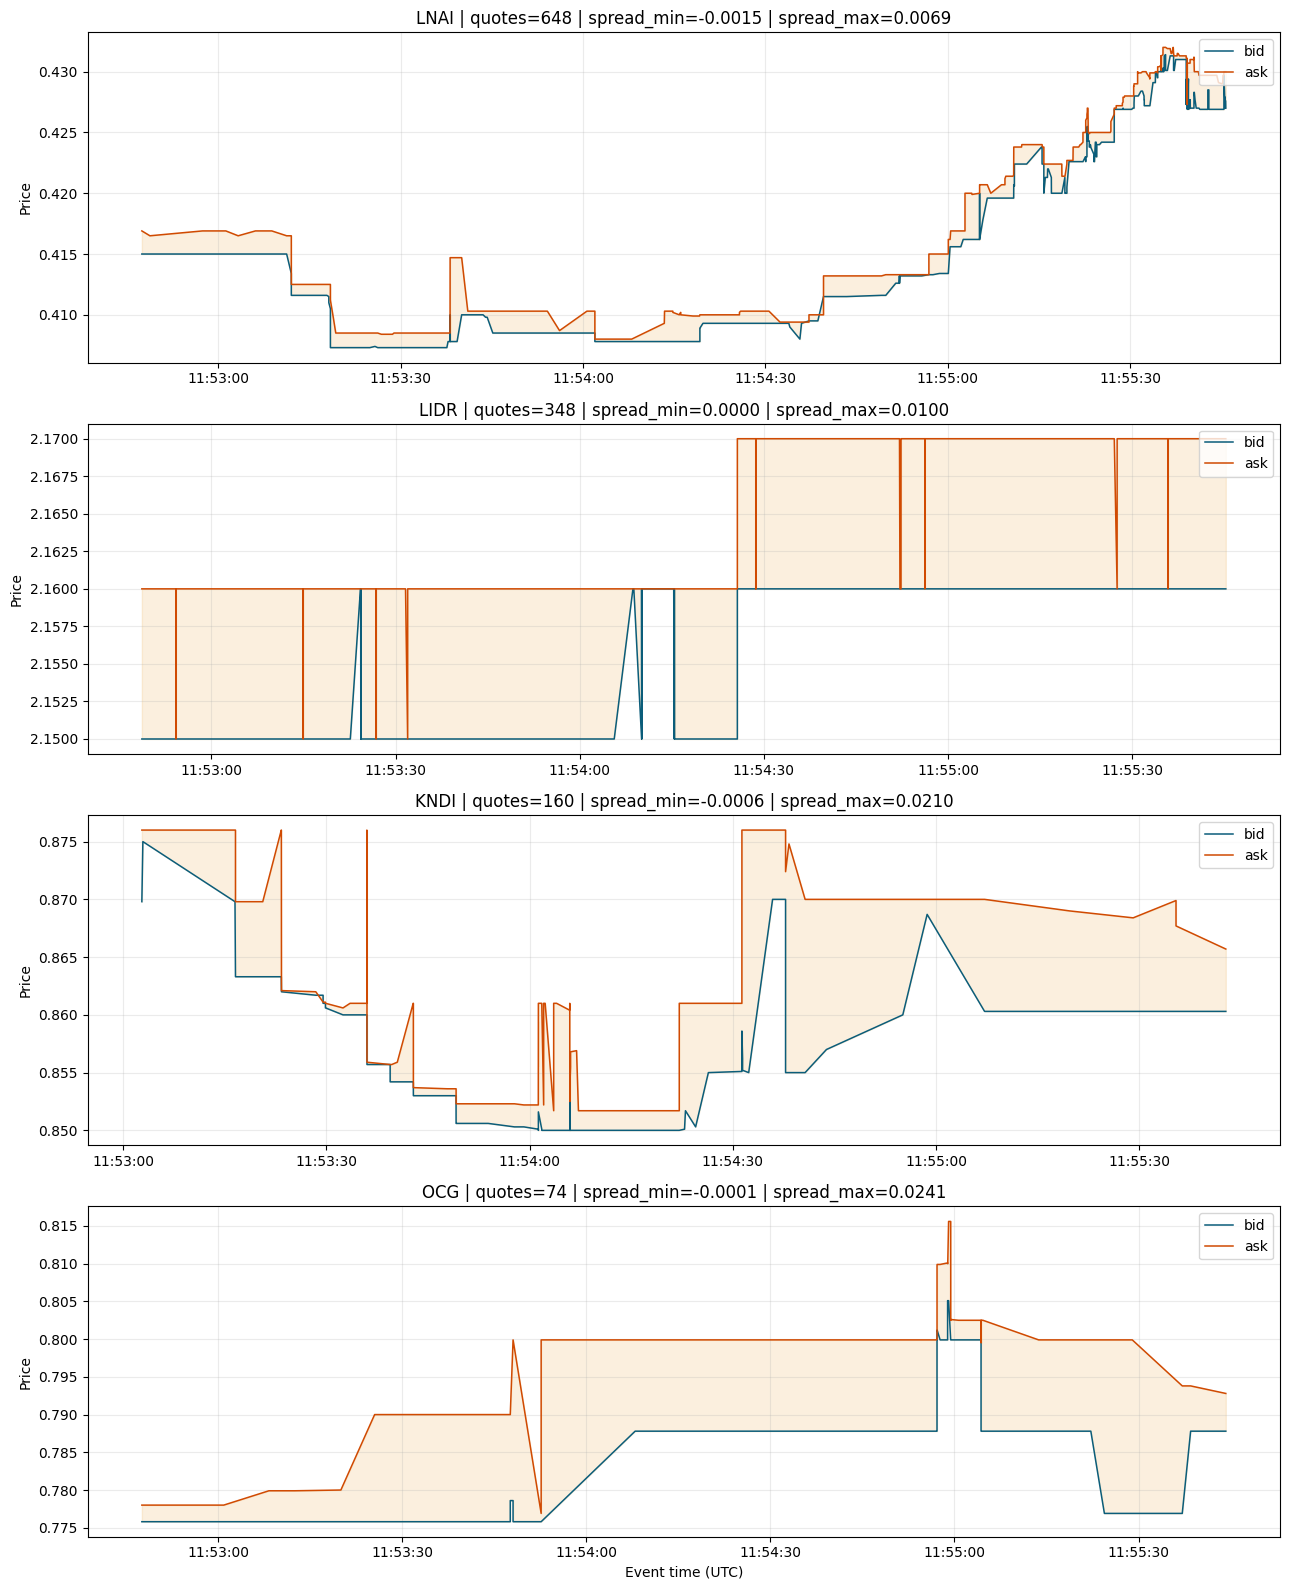

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

quotes_path = PROJECT_ROOT / "data" / "curated_ws" / label / "normalized" / "quotes.parquet"
if not quotes_path.exists():
    raise FileNotFoundError(f"No existe quotes.parquet: {quotes_path}")

df = pd.read_parquet(quotes_path).copy()
if df.empty:
    raise ValueError("El dataset de quotes est? vac?o para este run")

df["event_dt_utc"] = pd.to_datetime(df["event_time"], unit="ms", utc=True, errors="coerce")
df["spread"] = df["ask_price"] - df["bid_price"]
df = df.sort_values(["sym", "event_dt_utc", "sequence"]).reset_index(drop=True)

summary = df.groupby("sym").agg(
    quotes=("sym", "size"),
    min_bid=("bid_price", "min"),
    max_ask=("ask_price", "max"),
    min_spread=("spread", "min"),
    max_spread=("spread", "max")
).reset_index()
display(summary)

symbols = df["sym"].value_counts().head(4).index.tolist()
fig, axes = plt.subplots(len(symbols), 1, figsize=(13, max(4, 4 * len(symbols))), sharex=False)
if len(symbols) == 1:
    axes = [axes]

for ax, sym in zip(axes, symbols):
    data = df[df["sym"] == sym].copy()
    ax.plot(data["event_dt_utc"], data["bid_price"], label="bid", color="#0b5d7a", linewidth=1.1)
    ax.plot(data["event_dt_utc"], data["ask_price"], label="ask", color="#d04a02", linewidth=1.1)
    ax.fill_between(data["event_dt_utc"], data["bid_price"], data["ask_price"], color="#f1c27d", alpha=0.25)
    ax.set_title(
        f"{sym} | quotes={len(data)} | spread_min={data['spread'].min():.4f} | spread_max={data['spread'].max():.4f}"
    )
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Event time (UTC)")
plt.tight_layout()
plt.show()


## Celda 5. Preparaci?n del siguiente salto: a?adir `A`

Esta celda no captura nada todav?a. Su objetivo es dejar expl?cita la configuraci?n del siguiente run cuando quieras ampliar la fase 3 con `A` (aggregates por segundo).

Motivo: una vez validado `Q`, el siguiente paso natural es pasar de `AM,T,Q` a `AM,T,Q,A`, manteniendo el mismo flujo fase 1 -> fase 2 -> fase 3 sobre un nuevo `label`.

Resultado esperado: un bloque de configuraci?n listo para copiar a fase 1, fase 2 y fase 3 en el siguiente ciclo.

In [6]:
next_label = "prototype_run_phase3_A"
next_channels = "AM,T,Q,A"
next_symbols = phase3_symbols
next_duration_sec = phase3_duration_sec

print("CONFIGURACI?N SIGUIENTE RUN")
print(f"label = {next_label}")
print(f"channels = {next_channels}")
print(f"symbols = {next_symbols}")
print(f"duration_sec = {next_duration_sec}")


CONFIGURACI?N SIGUIENTE RUN
label = prototype_run_phase3_A
channels = AM,T,Q,A
symbols = LIDR,OCG,KNDI,LNAI
duration_sec = 180


  Fase 1
  Correcta.

  - fase1_realtime_polygon_prototype.ipynb
  - Config activa:
      - channels = "AM,T,Q,A"
      - symbols = "LIDR,OCG,KNDI,LNAI"
      - duration_sec = 180
      - label = "prototype_run_phase3_A"

  Fase 2
  Correcta.

  - fase2_realtime_polygon_analytics.ipynb
  - Config activa:
      - label = "prototype_run_phase3_A"

  Fase 3
  Correcta.

  - fase3_realtime_polygon_stream_expansion.ipynb
  - Config activa:
      - label = "prototype_run_phase3_A"
      - phase3_channels = "AM,T,Q,A"

  Resultado real del run prototype_run_phase3_A
  Fuente: capture_meta.json

  Has capturado:

  - T = 1761
  - Q = 1230
  - A = 182
  - AM = 12
  - status = 17

  Eso significa:

  - tape: sí
  - level 1 / top-of-book: sí
  - second aggregates: sí
  - minute aggregates: sí

  Normalización de fase 2
  Fuente: manifest.json

  Datasets ya generados:

  - trades = 1761
  - quotes = 1230
  - minute_aggs = 12
  - second_aggs = 182
  - status = 17

  Eso confirma que A ya entró bien y se transformó a:

  - second_aggs.parquet

  Conclusión

  - Fase 1: cerrada
  - Fase 2: cerrada
  - Fase 3 con Q: cerrada
  - Fase 3 ampliada con A: también conseguida

  O sea: el ciclo AM,T,Q,A ya está funcionando extremo a extremo.

  Qué haría ahora
  Ya no seguiría ampliando fase 3. El siguiente paso natural es Fase 4:

  - mover la lógica a backend/serving
  - dejar de depender del notebook como orquestador principal

  Si quieres, te propongo la estructura exacta de fase 4 para este proyecto.